# Superstore Sales Analysis
## Бизнес-вопрос: какие категории товаров приносят убыток и почему?

**Данные:** Sample Superstore — 9 994 заказа, США, 2014–2017  
**Инструменты:** Python, pandas, matplotlib

---


## 1. Загружаем библиотеки и данные

In [1]:
# Подключаем нужные библиотеки
import pandas as pd
import matplotlib.pyplot as plt

# Загружаем датасет
df = pd.read_csv('superstore_data.csv', encoding='latin-1')

# Смотрим первые строки
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 2. Первый взгляд на данные

In [2]:
# Сколько строк и колонок в таблице?
print('Размер таблицы:', df.shape)
print()

# Какие колонки есть?
print('Колонки:')
print(df.columns.tolist())


Размер таблицы: (9994, 21)

Колонки:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [3]:
# Проверяем — есть ли пропуски в данных?
print('Пропуски по колонкам:')
print(df.isnull().sum())


Пропуски по колонкам:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [4]:
# Смотрим базовую статистику по числовым колонкам
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe()


,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [5]:
# Общие итоги по всему магазину
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_margin = total_profit / total_sales * 100

print('Всего продаж:  ${:,.0f}'.format(total_sales))
print('Всего прибыли: ${:,.0f}'.format(total_profit))
print('Общая маржа:   {:.1f}%'.format(total_margin))


Всего продаж:  $2,297,201
Всего прибыли: $286,397
Общая маржа:   12.5%


## 3. Прибыль по категориям товаров

In [6]:
# Считаем продажи и прибыль по каждой категории
category_stats = df.groupby('Category').agg({'Sales': 'sum', 'Profit': 'sum'})
category_stats = category_stats.reset_index()

# Считаем маржу — прибыль делим на продажи
category_stats['Margin'] = category_stats['Profit'] / category_stats['Sales'] * 100
category_stats['Margin'] = category_stats['Margin'].round(1)

# Сортируем по прибыли — от большей к меньшей
category_stats = category_stats.sort_values('Profit', ascending=False)

print(category_stats)


          Category        Sales       Profit  Margin
2       Technology  836154.0330  145454.9481    17.4
1  Office Supplies  719047.0320  122490.8008    17.0
0        Furniture  741999.7953   18451.2728     2.5


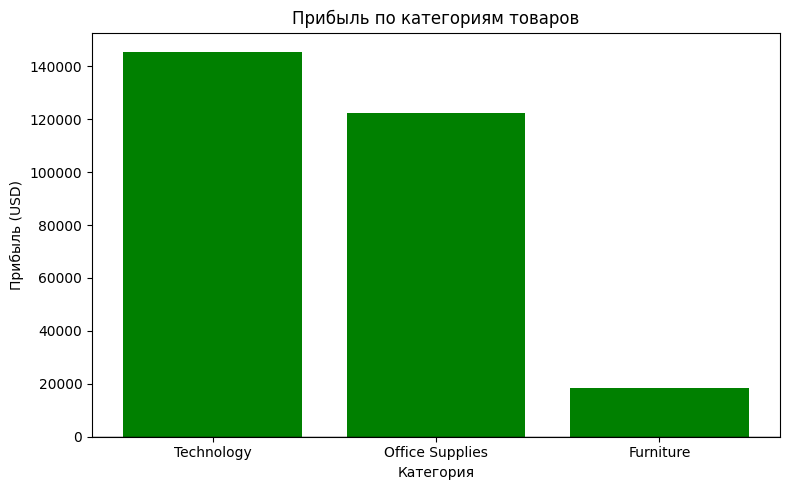

In [7]:
# Строим график прибыли по категориям
plt.figure(figsize=(8, 5))

# Выбираем цвет: зелёный если прибыль > 0, красный если убыток
bar_colors = []
for profit in category_stats['Profit']:
    if profit > 0:
        bar_colors.append('green')
    else:
        bar_colors.append('red')

plt.bar(category_stats['Category'], category_stats['Profit'], color=bar_colors)
plt.title('Прибыль по категориям товаров')
plt.xlabel('Категория')
plt.ylabel('Прибыль (USD)')
plt.axhline(0, color='black', linewidth=1)  # нулевая линия
plt.tight_layout()
plt.savefig('category_profit.png', dpi=150)
plt.show()


**Вывод:** Все три категории прибыльны, но маржа сильно отличается:
- Technology — **17.4%** маржа
- Office Supplies — **17.0%** маржа  
- Furniture — всего **2.5%** маржа

Мебель генерирует 41% продаж, но только 6% прибыли. Идём глубже.


## 4. Подкатегории — где конкретно убытки?

In [8]:
# Считаем прибыль по каждой подкатегории
subcat_stats = df.groupby('Sub-Category').agg({'Sales': 'sum', 'Profit': 'sum'})
subcat_stats = subcat_stats.reset_index()

# Считаем маржу
subcat_stats['Margin'] = subcat_stats['Profit'] / subcat_stats['Sales'] * 100
subcat_stats['Margin'] = subcat_stats['Margin'].round(1)

# Сортируем — убыточные будут сверху
subcat_stats = subcat_stats.sort_values('Profit')

print(subcat_stats)


   Sub-Category        Sales      Profit  Margin
16       Tables  206965.5320 -17725.4811    -8.6
4     Bookcases  114879.9963  -3472.5560    -3.0
15     Supplies   46673.5380  -1189.0995    -2.5
8     Fasteners    3024.2800    949.5182    31.4
11     Machines  189238.6310   3384.7569     1.8
10       Labels   12486.3120   5546.2540    44.4
2           Art   27118.7920   6527.7870    24.1
7     Envelopes   16476.4020   6964.1767    42.3
9   Furnishings   91705.1640  13059.1436    14.2
1    Appliances  107532.1610  18138.0054    16.9
14      Storage  223843.6080  21278.8264     9.5
5        Chairs  328449.1030  26590.1663     8.1
3       Binders  203412.7330  30221.7633    14.9
12        Paper   78479.2060  34053.5693    43.4
0   Accessories  167380.3180  41936.6357    25.1
13       Phones  330007.0540  44515.7306    13.5
6       Copiers  149528.0300  55617.8249    37.2


In [9]:
# Выводим только убыточные подкатегории
losers = subcat_stats[subcat_stats['Profit'] < 0]

print('УБЫТОЧНЫЕ ПОДКАТЕГОРИИ:')
print()
for index, row in losers.iterrows():
    print('Подкатегория: {}'.format(row['Sub-Category']))
    print('  Продажи:  ${:,.0f}'.format(row['Sales']))
    print('  Убыток:   ${:,.0f}'.format(row['Profit']))
    print('  Маржа:    {:.1f}%'.format(row['Margin']))
    print()


УБЫТОЧНЫЕ ПОДКАТЕГОРИИ:

Подкатегория: Tables
  Продажи:  $206,966
  Убыток:   $-17,725
  Маржа:    -8.6%

Подкатегория: Bookcases
  Продажи:  $114,880
  Убыток:   $-3,473
  Маржа:    -3.0%

Подкатегория: Supplies
  Продажи:  $46,674
  Убыток:   $-1,189
  Маржа:    -2.5%



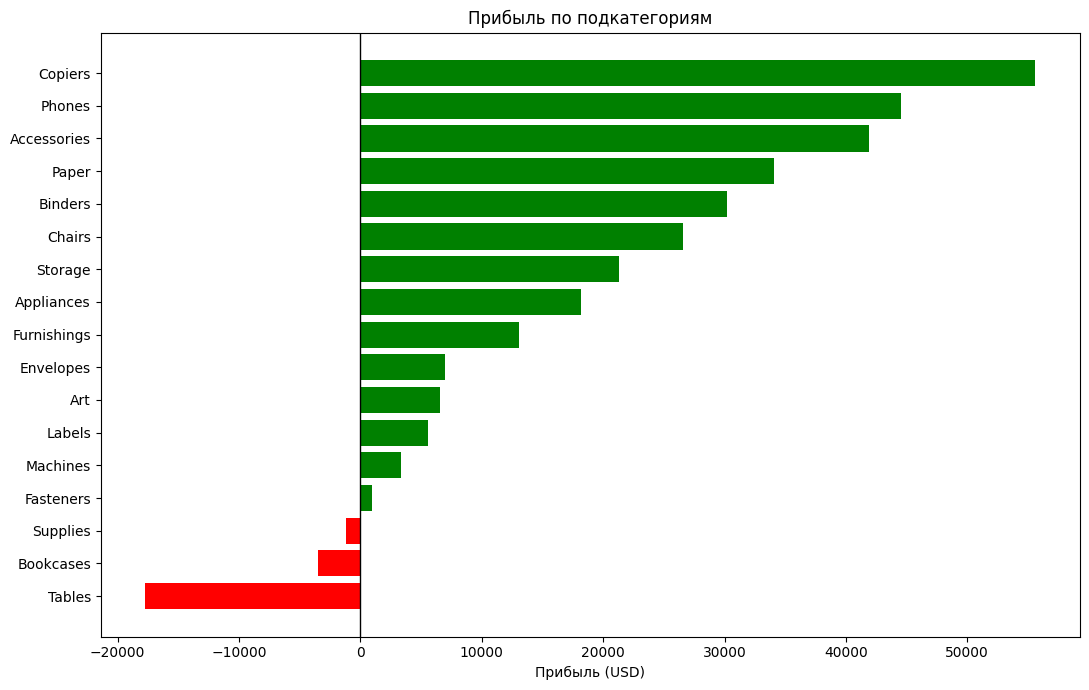

In [10]:
# Горизонтальный bar chart — удобен когда названий много
plt.figure(figsize=(11, 7))

# Цвета: красный = убыток, зелёный = прибыль
bar_colors = []
for profit in subcat_stats['Profit']:
    if profit < 0:
        bar_colors.append('red')
    else:
        bar_colors.append('green')

plt.barh(subcat_stats['Sub-Category'], subcat_stats['Profit'], color=bar_colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Прибыль по подкатегориям')
plt.xlabel('Прибыль (USD)')
plt.tight_layout()
plt.savefig('subcategory_profit.png', dpi=150)
plt.show()


**Вывод:**  
- **Tables** — убыток $17 725 (маржа -8.6%)  
- **Bookcases** — убыток $3 472 (маржа -3.0%)  
- **Supplies** — убыток $1 189 (маржа -2.5%)  

Все три — это мебель или около того. Почему они убыточны? Проверяем скидки.


## 5. Влияние скидок на прибыль

In [11]:
# Смотрим как скидка связана с прибылью
# Считаем корреляцию — если -1, то чем больше скидка, тем меньше прибыль
correlation = df['Discount'].corr(df['Profit'])
print('Корреляция между скидкой и прибылью:', round(correlation, 3))
print()
print('Значение от -1 до 1.')
print('Отрицательное — скидка снижает прибыль.')


Корреляция между скидкой и прибылью: -0.219

Значение от -1 до 1.
Отрицательное — скидка снижает прибыль.


In [12]:
# Разбиваем заказы на группы по размеру скидки
df['discount_group'] = '0%'

for i in df.index:
    discount = df.loc[i, 'Discount']
    if discount == 0:
        df.loc[i, 'discount_group'] = '0%'
    elif discount <= 0.10:
        df.loc[i, 'discount_group'] = '1-10%'
    elif discount <= 0.20:
        df.loc[i, 'discount_group'] = '11-20%'
    elif discount <= 0.30:
        df.loc[i, 'discount_group'] = '21-30%'
    elif discount <= 0.50:
        df.loc[i, 'discount_group'] = '31-50%'
    else:
        df.loc[i, 'discount_group'] = '51%+'

# Средняя прибыль по каждой группе
discount_profit = df.groupby('discount_group')['Profit'].mean()
discount_profit = discount_profit.round(1)

print('Средняя прибыль на заказ по размеру скидки:')
print(discount_profit)


Средняя прибыль на заказ по размеру скидки:
discount_group
0%         66.9
1-10%      96.1
11-20%     24.7
21-30%    -45.7
31-50%   -156.3
51%+      -89.4
Name: Profit, dtype: float64


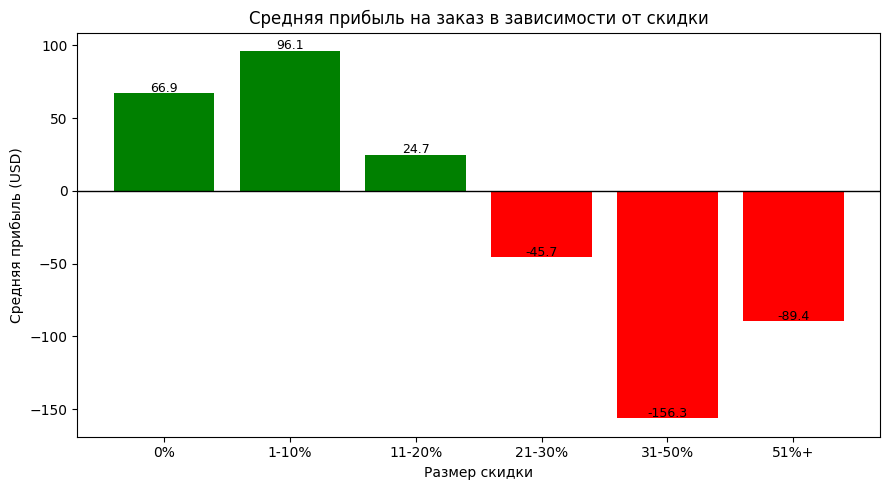

In [13]:
# График: средняя прибыль по группам скидок
groups = ['0%', '1-10%', '11-20%', '21-30%', '31-50%', '51%+']
profits = []

for group in groups:
    avg = df[df['discount_group'] == group]['Profit'].mean()
    profits.append(round(avg, 1))

# Цвет: красный если прибыль отрицательная
bar_colors = []
for p in profits:
    if p < 0:
        bar_colors.append('red')
    else:
        bar_colors.append('green')

plt.figure(figsize=(9, 5))
plt.bar(groups, profits, color=bar_colors)
plt.axhline(0, color='black', linewidth=1)
plt.title('Средняя прибыль на заказ в зависимости от скидки')
plt.xlabel('Размер скидки')
plt.ylabel('Средняя прибыль (USD)')

# Подписи на столбиках
for i in range(len(groups)):
    plt.text(i, profits[i] + 1, str(profits[i]), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('discount_profit.png', dpi=150)
plt.show()


**Вывод:** Скидка выше 20% — зона убытков.

| Скидка | Средняя прибыль |
|--------|----------------|
| 0% | +$66.9 |
| 1–10% | +$96.1 |
| 11–20% | +$24.7 |
| **21–30%** | **−$45.7** |
| **31–50%** | **−$156.3** |
| **51%+** | **−$89.4** |

Именно в этой зоне находятся Tables и Bookcases.


In [14]:
# Проверяем: какая средняя скидка у убыточных подкатегорий?
problem_items = ['Tables', 'Bookcases', 'Supplies']

print('Средняя скидка по убыточным подкатегориям:')
print()
for item in problem_items:
    avg_discount = df[df['Sub-Category'] == item]['Discount'].mean()
    avg_profit = df[df['Sub-Category'] == item]['Profit'].mean()
    print('{}: скидка {:.0f}%, средняя прибыль на заказ ${:.1f}'.format(
        item, avg_discount * 100, avg_profit))


Средняя скидка по убыточным подкатегориям:

Tables: скидка 26%, средняя прибыль на заказ $-55.6
Bookcases: скидка 21%, средняя прибыль на заказ $-15.2
Supplies: скидка 8%, средняя прибыль на заказ $-6.3


## 6. Региональный анализ

In [15]:
# Прибыль по регионам
region_stats = df.groupby('Region').agg({'Sales': 'sum', 'Profit': 'sum'})
region_stats = region_stats.reset_index()
region_stats['Margin'] = region_stats['Profit'] / region_stats['Sales'] * 100
region_stats['Margin'] = region_stats['Margin'].round(1)
region_stats = region_stats.sort_values('Profit', ascending=False)

print(region_stats)


    Region        Sales       Profit  Margin
3     West  725457.8245  108418.4489    14.9
1     East  678781.2400   91522.7800    13.5
2    South  391721.9050   46749.4303    11.9
0  Central  501239.8908   39706.3625     7.9


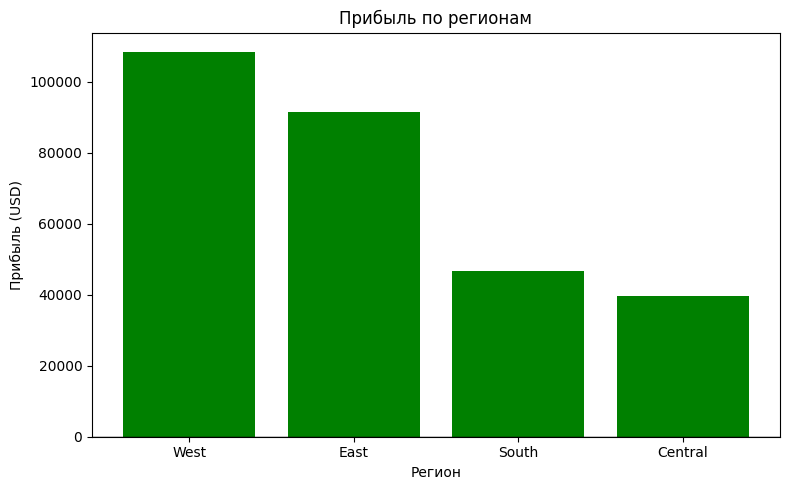

In [16]:
# График по регионам
plt.figure(figsize=(8, 5))

bar_colors = []
for profit in region_stats['Profit']:
    if profit > 0:
        bar_colors.append('green')
    else:
        bar_colors.append('red')

plt.bar(region_stats['Region'], region_stats['Profit'], color=bar_colors)
plt.title('Прибыль по регионам')
plt.xlabel('Регион')
plt.ylabel('Прибыль (USD)')
plt.axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.savefig('region_profit.png', dpi=150)
plt.show()


In [17]:
# Топ-10 штатов с наибольшими убытками
state_stats = df.groupby('State').agg({'Sales': 'sum', 'Profit': 'sum'})
state_stats = state_stats.reset_index()
state_stats = state_stats.sort_values('Profit')

# Берём первые 10 — самые убыточные
bottom_10 = state_stats.head(10)

print('Топ-10 убыточных штатов:')
print(bottom_10[['State', 'Sales', 'Profit']])


Топ-10 убыточных штатов:
             State        Sales      Profit
41           Texas  170188.0458 -25729.3563
33            Ohio   78258.1360 -16971.3766
36    Pennsylvania  116511.9140 -15559.9603
11        Illinois   80166.1010 -12607.8870
31  North Carolina   55603.1640  -7490.9122
4         Colorado   32108.1180  -6527.8579
40       Tennessee   30661.8730  -5341.6936
1          Arizona   35282.0010  -3427.9246
8          Florida   89473.7080  -3399.3017
35          Oregon   17431.1500  -1190.4705


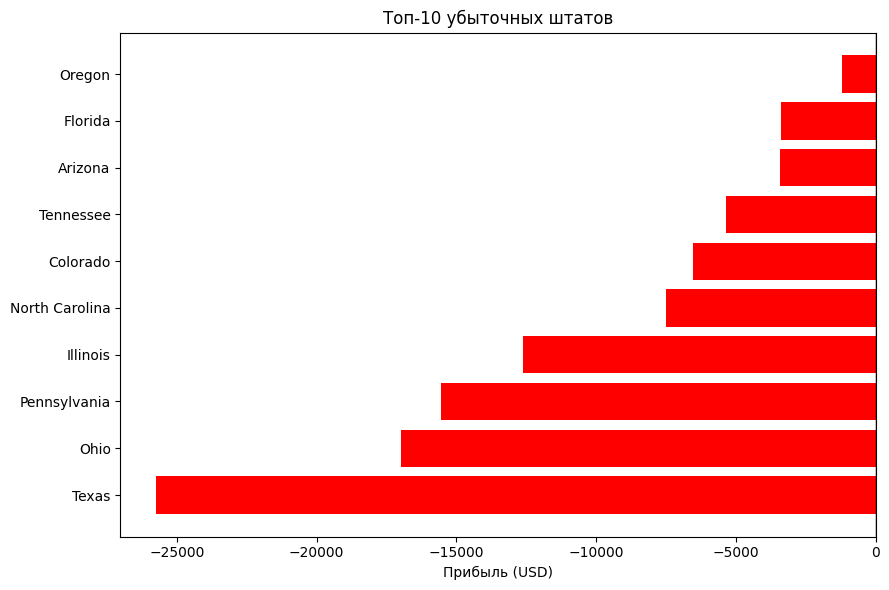

In [18]:
# Горизонтальный chart по убыточным штатам
plt.figure(figsize=(9, 6))

plt.barh(bottom_10['State'], bottom_10['Profit'], color='red')
plt.axvline(0, color='black', linewidth=1)
plt.title('Топ-10 убыточных штатов')
plt.xlabel('Прибыль (USD)')
plt.tight_layout()
plt.savefig('states_loss.png', dpi=150)
plt.show()


## 7. Итоги и рекомендации

---

### Что нашли

**Убыточные подкатегории:**
- Tables — убыток $17 725 (маржа -8.6%)
- Bookcases — убыток $3 472 (маржа -3.0%)
- Supplies — убыток $1 189 (маржа -2.5%)

**Главная причина убытков — скидки выше 20%.**  
При скидке 21–30% средняя прибыль на заказ становится отрицательной (−$45.7).

**Лидеры прибыли:**
- Copiers — $55 618 (маржа 37.2%)
- Phones — $44 516 (маржа 13.5%)
- Accessories — $41 937 (маржа 25.1%)

---

### Рекомендации бизнесу

1. **Ввести правило: скидка выше 20% требует согласования** — это главный источник убытков
2. **Пересмотреть ценообразование на Tables** — они убыточны даже без скидок
3. **Для Bookcases** — убрать высокие скидки, продукт может стать прибыльным
4. **Инвестировать в развитие Copiers и Technology** — там самая высокая маржа
5. **Аудит Texas и Ohio** — два самых убыточных штата

---

### Ключевой вывод

> Superstore не проигрывает в объёме продаж.  
> Проблема — в неконтролируемых скидках.  
> Одно изменение в политике скидок способно вернуть $25–30K прибыли в год.


In [19]:
# Итоговая сводка цифр
print('=' * 50)
print('ИТОГИ АНАЛИЗА')
print('=' * 50)

print()
print('Общие показатели:')
print('  Продажи:  ${:,.0f}'.format(df['Sales'].sum()))
print('  Прибыль:  ${:,.0f}'.format(df['Profit'].sum()))
print('  Маржа:    {:.1f}%'.format(df['Profit'].sum() / df['Sales'].sum() * 100))

print()
print('Убыточные подкатегории:')
print('  Tables:    -$17,725  (маржа -8.6%)')
print('  Bookcases:  -$3,472  (маржа -3.0%)')
print('  Supplies:   -$1,189  (маржа -2.5%)')

print()
print('Потери от скидок > 20%:')
loss = df[df['Discount'] > 0.2]['Profit'].sum()
print('  ${:,.0f}'.format(loss))

print()
print('Лучшие подкатегории по прибыли:')
print('  Copiers:      $55,618  (маржа 37.2%)')
print('  Phones:       $44,516  (маржа 13.5%)')
print('  Accessories:  $41,937  (маржа 25.1%)')
print('=' * 50)


ИТОГИ АНАЛИЗА

Общие показатели:
  Продажи:  $2,297,201
  Прибыль:  $286,397
  Маржа:    12.5%

Убыточные подкатегории:
  Tables:    -$17,725  (маржа -8.6%)
  Bookcases:  -$3,472  (маржа -3.0%)
  Supplies:   -$1,189  (маржа -2.5%)

Потери от скидок > 20%:
  $-135,376

Лучшие подкатегории по прибыли:
  Copiers:      $55,618  (маржа 37.2%)
  Phones:       $44,516  (маржа 13.5%)
  Accessories:  $41,937  (маржа 25.1%)
